# Analysis of Omni-iEEG dataset, detection of HFO events

HFOs:
- They are spontaneous iEEG events in the 80–500 Hz frequency range
- characterized by at least four consecutive oscillations that clearly stand out from the background activity
- 30 to 1000 ms in duration


HFOs are typically divided into two bands:
- Ripples (80–250 Hz)
- Fast ripples (250–500 Hz)

Nyquist frequency: need a sampling frequency the double of the highest frequency of interest.

In [10]:
import os
import h5py
from torch_brain.data import Data
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from scipy.signal import spectrogram

In [11]:
# BIDS_ROOT = ("/capstor/scratch/cscs/davalos/data/processed/omni_ieeg")
# H5_FILENAME = "sub-openieegDetroit078_ses-01_task-sleep.h5"
BIDS_ROOT = "/Users/avalos/Documents/Programming/neurosoft_epilepsy/data/processed/omni_ieeg"
H5_FILENAME = "sub-openieegDetroit006_ses-01_task-sleep.h5"

### 1. Load .h5 file

In [12]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)

    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  annotations
   -  brainset
   -  channels
   -  device
   -  ieeg
   -  session
   -  subject
   -  dataset_name
   -  outcome
   -  split
   -  task_name


In [13]:
print(data.annotations)

Interval(
  start=[332],
  end=[332],
  artifact=[332],
  channel=[332],
  description=[332],
  detector=[332],
  method=[332],
  spike=[332]
)


In [14]:
for i in np.arange(1,10):
    print(data.annotations.channel[i])
    print(data.annotations.start[i])
    print(data.annotations.end[i])
    print(data.annotations.artifact[i])

b'A2-AV'
101.931
101.962
1
b'A3-AV'
188.845
188.898
0
b'A3-AV'
188.909
188.926
0
b'A3-AV'
188.94
189.15
0
b'A3-AV'
189.166
189.214
0
b'A3-AV'
189.225
189.247
0
b'A3-AV'
189.258
189.367
0
b'A3-AV'
189.381
189.4
0
b'A3-AV'
189.412
189.431
0


In [15]:
data.ieeg

RegularTimeSeries(
  signal=[304000, 100]
)

### 2. Channels info

In [16]:
print("Channel names: ", data.channels.id[1:5])
print("Channel types: ", data.channels.type[1:5])

Channel names:  ['A2-AV' 'A3-AV' 'A4-AV' 'A5-AV']
Channel types:  ['eeg' 'eeg' 'eeg' 'eeg']


In [17]:
ch_names = data.channels.id
ch_types = data.channels.type
start_time = 0
signal = data.ieeg.signal  # ecog
timestamps = data.ieeg.timestamps  # ecog
timestamps
len(ch_names)

100

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/1481876644.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


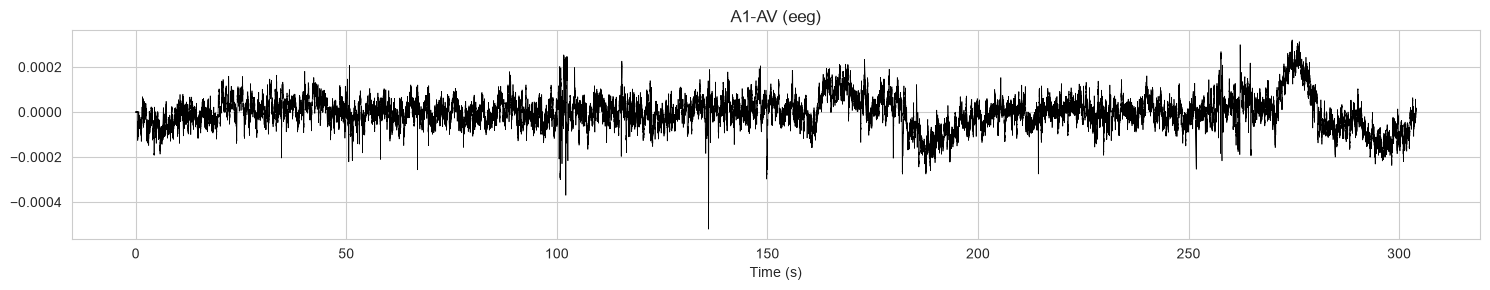

In [18]:
def plot_channel(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        timestamps[keep],
        signal[keep, channel_idx],
        color="black",
        linewidth=0.5,
    )
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]})")
    fig.tight_layout()
    return fig


fig = plot_channel(
    signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=start_time
)
fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/3054376546.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


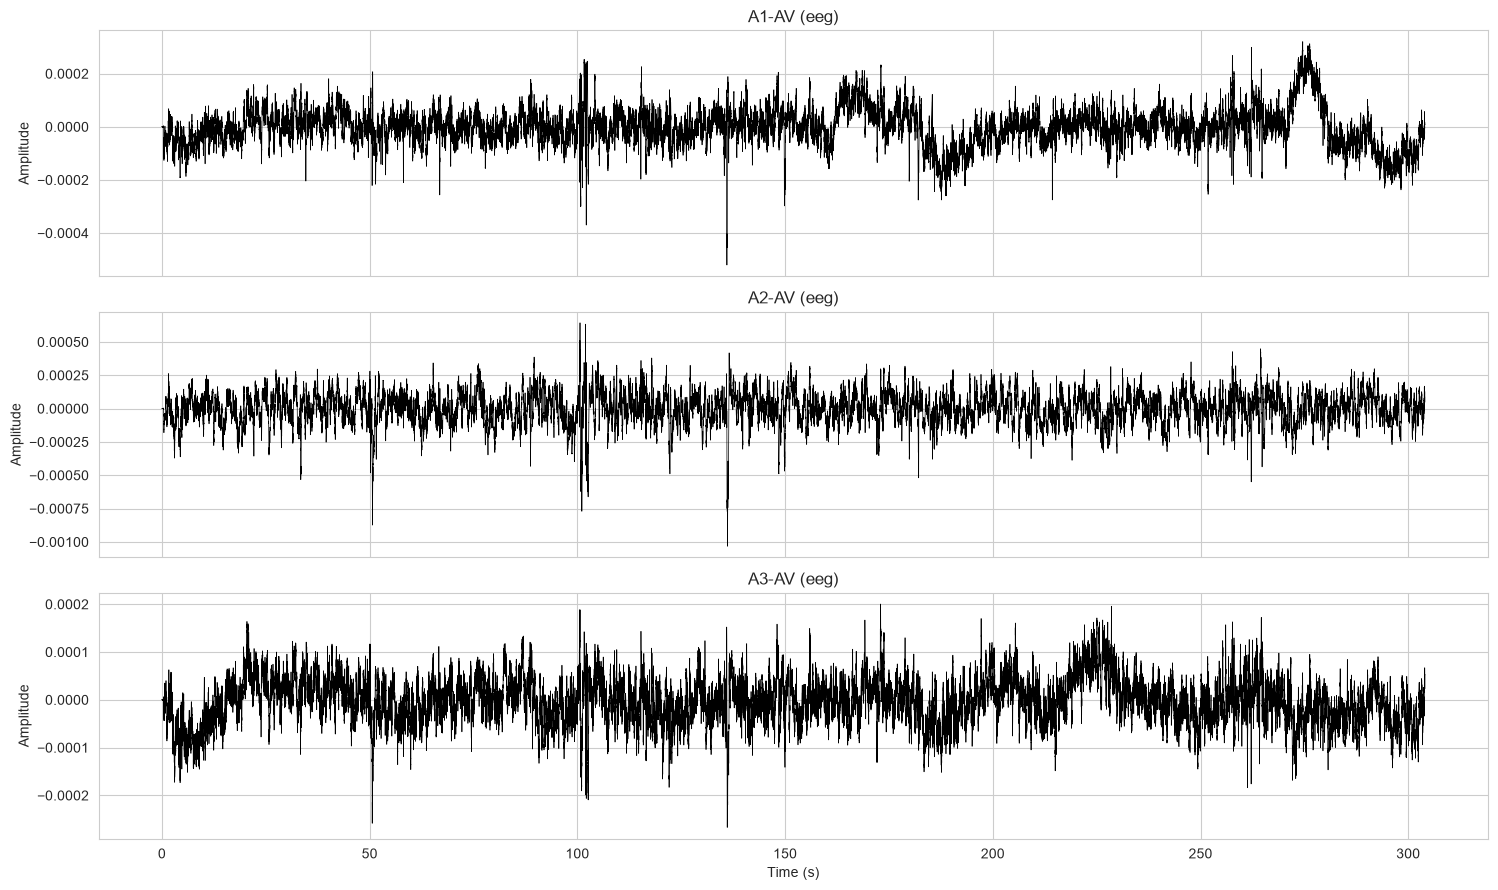

In [19]:
def plot_channels(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_indices: list[int] = [0, 1, 2],
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):

    n = len(channel_indices)

    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, axes = plt.subplots(
        n, 1, figsize=(figsize[0], figsize[1] * n), sharex=True
    )

    if n == 1:
        axes = [axes]  # make it iterable when there's only one channel

    for ax, ch_idx in zip(axes, channel_indices):
        ax.plot(
            timestamps[keep], signal[keep, ch_idx], color="black", linewidth=0.5
        )
        ax.set_title(f"{ch_names[ch_idx]} ({ch_types[ch_idx]})")
        ax.set_ylabel("Amplitude")

    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    return fig


fig = plot_channels(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_indices=np.arange(len(ch_names[0:3])),
    start_time=0,
    end_time=None,
    figsize=(15, 3),
)
fig.show()

### 3. iEEG data visualization

In [20]:
def plot_channel_with_hfo_events(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    annotations,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):
    """Plot one channel's raw signal with its doctor-annotated HFO events shaded.

    `annotations` is `data.annotations` after merging in HFO events (see
    `foundry.data.pipelines.omni_ieeg._build_annotations`) -- each event has a
    `channel`, `start`/`end` (seconds) and an `artifact` flag (1 = doctor
    marked it as an artifact, not a true HFO).
    """
    fig = plot_channel(
        signal,
        timestamps,
        ch_names,
        ch_types,
        channel_idx,
        start_time,
        end_time,
        figsize,
    )
    ax = fig.axes[0]

    ch_name = ch_names[channel_idx]
    on_channel = annotations.channel.astype(str) == ch_name

    legend_handles = {}
    for ev_start, ev_end, artifact in zip(
        annotations.start[on_channel],
        annotations.end[on_channel],
        annotations.artifact[on_channel],
    ):
        if (
            ev_start > (end_time if end_time is not None else timestamps[-1])
            or ev_end < start_time
        ):
            continue
        label = "HFO (artifact)" if artifact == 1 else "HFO"
        color = "red" if artifact == 1 else "orange"
        ax.axvspan(ev_start, ev_end, color=color, alpha=0.3, lw=0)
        legend_handles[label] = Patch(facecolor=color, alpha=0.3, label=label)

    if legend_handles:
        ax.legend(handles=list(legend_handles.values()), loc="upper right")
    return fig

In [21]:
ch_names

array(['A1-AV', 'A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV',
       'A8-AV', 'A9-AV', 'A10-AV', 'A11-AV', 'A12-AV', 'A13-AV', 'A14-AV',
       'A15-AV', 'A16-AV', 'A17-AV', 'A18-AV', 'A19-AV', 'A20-AV',
       'A21-AV', 'A22-AV', 'A23-AV', 'A24-AV', 'A25-AV', 'A26-AV',
       'A27-AV', 'A28-AV', 'A29-AV', 'A30-AV', 'A31-AV', 'A32-AV',
       'A33-AV', 'A34-AV', 'A35-AV', 'A36-AV', 'A37-AV', 'A38-AV',
       'A39-AV', 'A40-AV', 'A41-AV', 'A42-AV', 'A43-AV', 'A44-AV',
       'A45-AV', 'A46-AV', 'A47-AV', 'A48-AV', 'A49-AV', 'A50-AV',
       'A51-AV', 'A52-AV', 'A53-AV', 'A54-AV', 'A55-AV', 'A56-AV',
       'A57-AV', 'A58-AV', 'A59-AV', 'A60-AV', 'A61-AV', 'A62-AV',
       'A63-AV', 'A64-AV', 'B1-AV', 'B2-AV', 'B3-AV', 'B4-AV', 'B5-AV',
       'B6-AV', 'B7-AV', 'B8-AV', 'B9-AV', 'B10-AV', 'B11-AV', 'B12-AV',
       'B13-AV', 'B14-AV', 'B15-AV', 'B16-AV', 'B17-AV', 'B18-AV',
       'B19-AV', 'B20-AV', 'B21-AV', 'B22-AV', 'B23-AV', 'B24-AV',
       'B25-AV', 'B26-AV', 'B27-AV', 'B2

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/1883218828.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


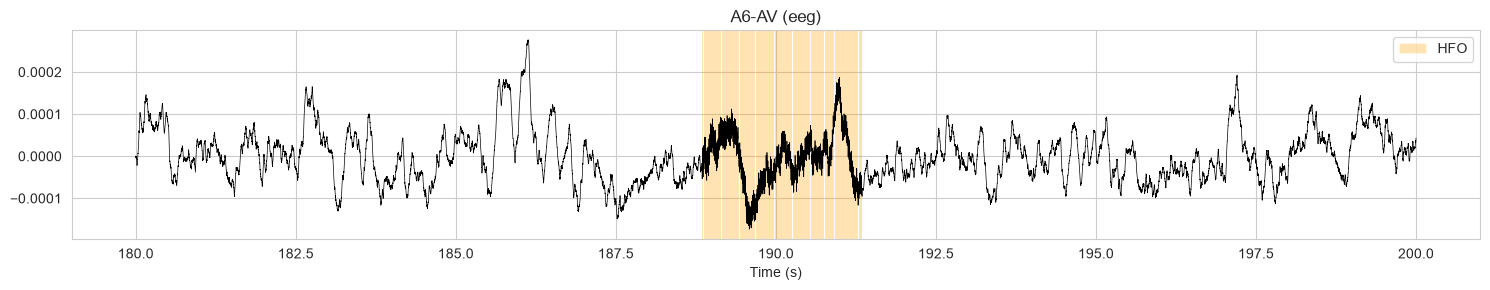

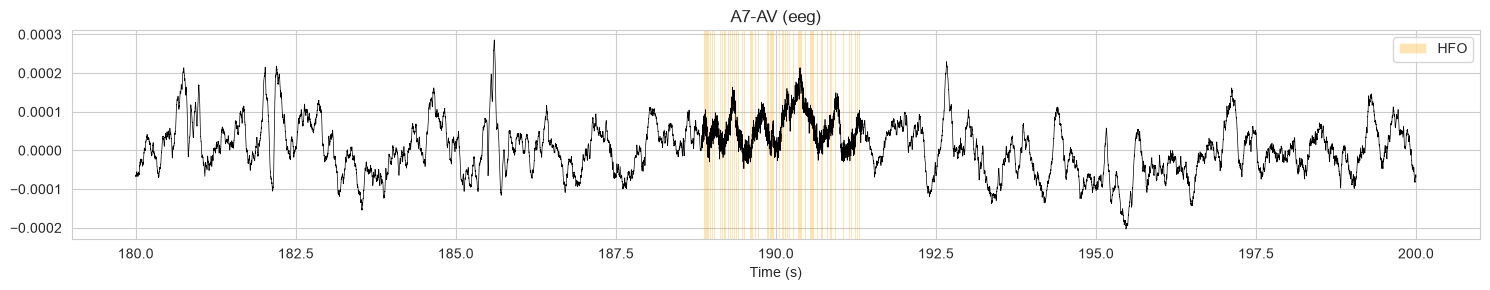

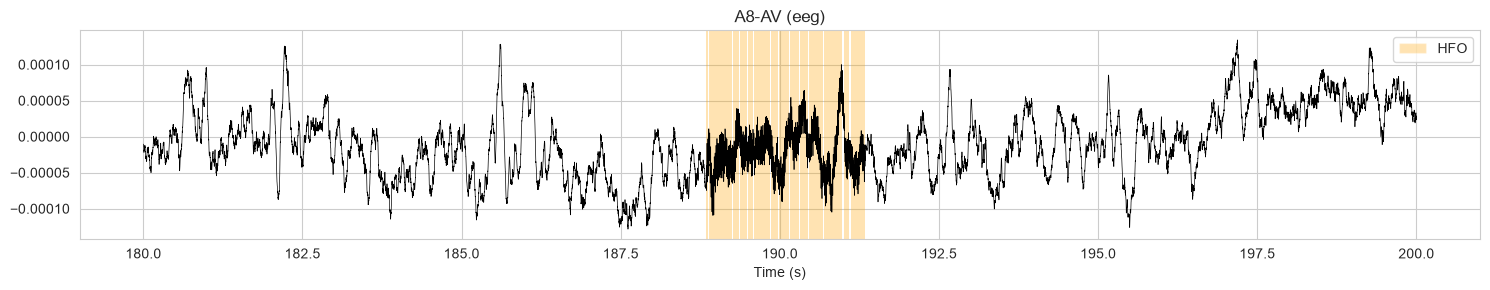

In [22]:
for ch_nbr in np.arange(5, 8):
    fig = plot_channel_with_hfo_events(
        signal,
        timestamps,
        ch_names,
        ch_types,
        data.annotations,
        channel_idx=ch_nbr,
        start_time=180,
        end_time=200,
    )
    fig.show()

In [23]:
def plot_channel_spectrogram(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
    figsize=(15, 3),
):
    """Plot a spectrogram of one channel using a sliding window.

    `window_ms` is the length of each FFT segment; `step_ms` is how far the
    window slides between segments (so overlap = window_ms - step_ms).
    """
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(
        trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap
    )

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
    )
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(
        f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram"
    )
    fig.tight_layout()
    return fig

In [24]:
def get_spectral_data(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(
        trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap
    )
    return t, freqs, times, sxx

In [25]:
def plot_spectrogram(t, freqs, times, sxx, channel_idx, figsize):
    # TODO add type hints
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
    )
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(
        f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram"
    )
    fig.tight_layout()
    return fig

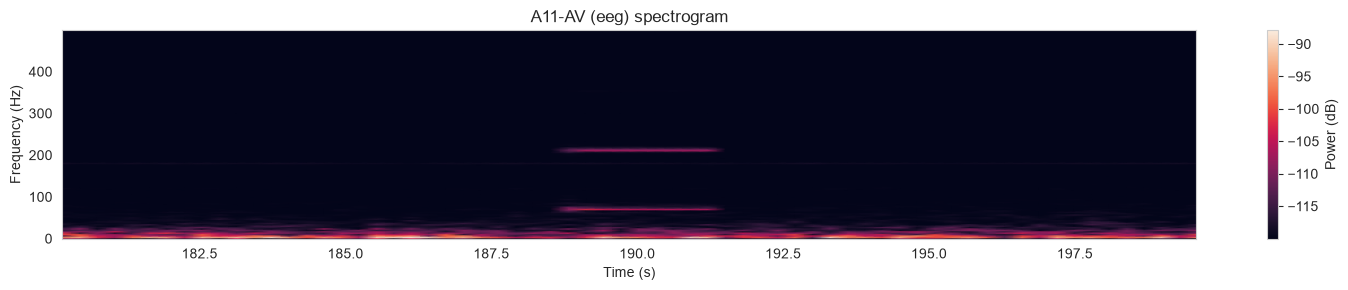

In [26]:
t, freqs, times, sxx = get_spectral_data(
    signal,
    timestamps,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=300,
    step_ms=300,
)

fig = plot_spectrogram(t, freqs, times, sxx, 10, figsize=(15, 3))

In [27]:
print(freqs.shape)
print(times.shape)
print(sxx.shape)

(150,)
(66,)
(150, 66)


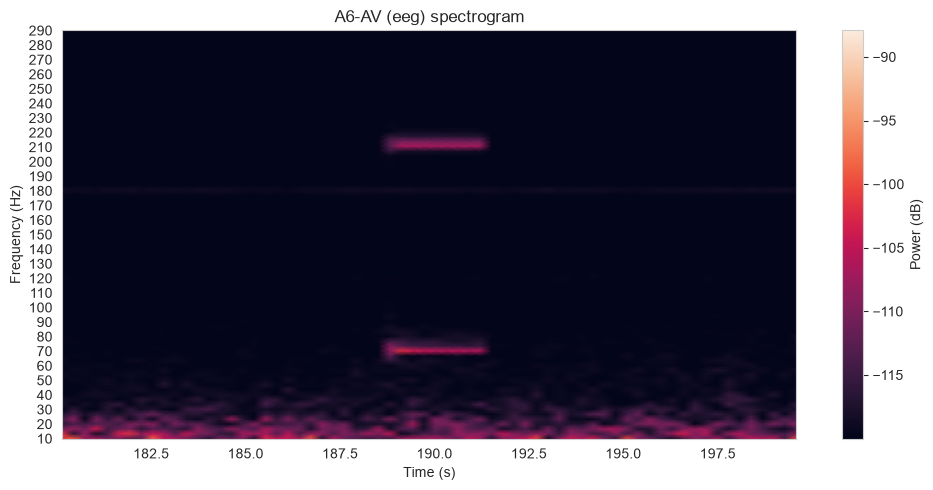

In [28]:
channel_idx = 5
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
)
fig.colorbar(mesh, ax=ax, label="Power (dB)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram")
ax.set_yticks(np.arange(0, freqs[-1] + 1, 10))  # tick every 10 Hz
ax.set_ylim(10, 290)
fig.tight_layout()

In [29]:
def plot_channel_spectra(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_names: list = None,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
    freq_range: tuple = (10, 500),
    db_scale: bool = True,
    highlight_hfo_bands: bool = True,
    ax=None,
):
    """
    Overlay averaged power spectra for all channels, for HFO screening.

    Parameters
    ----------
    signal : np.ndarray, shape (n_samples, n_channels)
    timestamps : np.ndarray, shape (n_samples,)
    channel_names : list of str, optional (defaults to "Ch0", "Ch1", ...)
    freq_range : tuple, x-axis limits in Hz (default 10-500 to cover ripples + fast ripples)
    db_scale : if True, plot 10*log10(power)
    highlight_hfo_bands : shades ripple (80-250 Hz) and fast ripple (250-500 Hz) bands
    ax : optional matplotlib Axes to plot into
    """
    n_channels = signal.shape[1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    for ch in range(n_channels):
        t, freqs, times, sxx = get_spectral_data(
            signal,
            timestamps,
            channel_idx=ch,
            start_time=start_time,
            end_time=end_time,
            window_ms=window_ms,
            step_ms=step_ms,
        )
        power = sxx.mean(axis=1)
        y = 10 * np.log10(power + 1e-20) if db_scale else power
        ax.plot(freqs, y, label=channel_names[ch], linewidth=1)

    if highlight_hfo_bands:
        ax.axvspan(
            80, 250, color="orange", alpha=0.1, label="Ripple (80-250 Hz)"
        )
        ax.axvspan(
            250, 500, color="red", alpha=0.1, label="Fast ripple (250-500 Hz)"
        )

    ax.set_xlim(freq_range)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)" if db_scale else "Power")
    ax.set_title("Power Spectrum by Channel")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    return ax

In [30]:
ch_names[1:10]

array(['A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV', 'A8-AV',
       'A9-AV', 'A10-AV'], dtype='<U6')

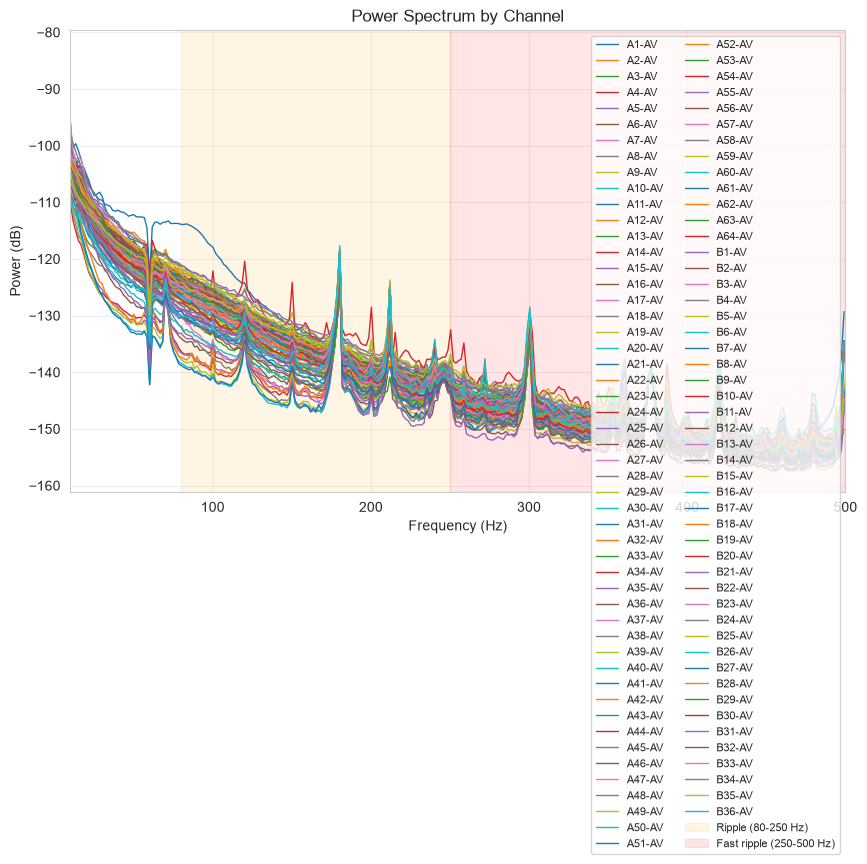

In [31]:
plot_channel_spectra(signal, timestamps, channel_names=ch_names[:])
plt.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/1273006006.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/1273006006.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


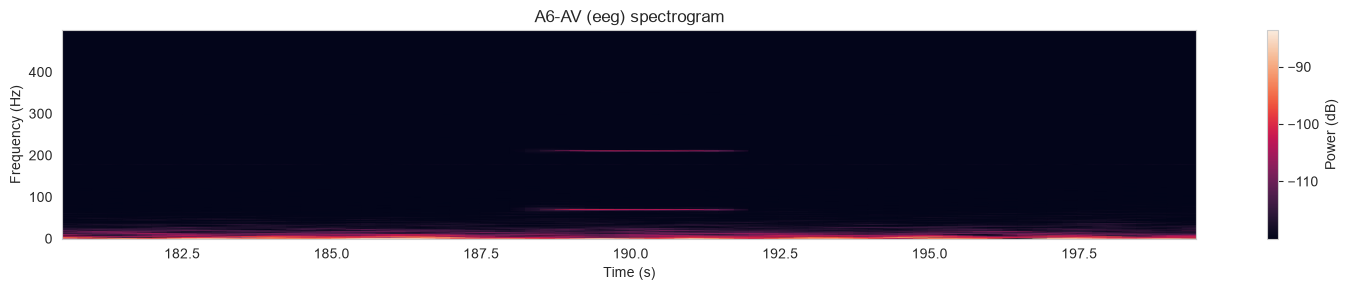

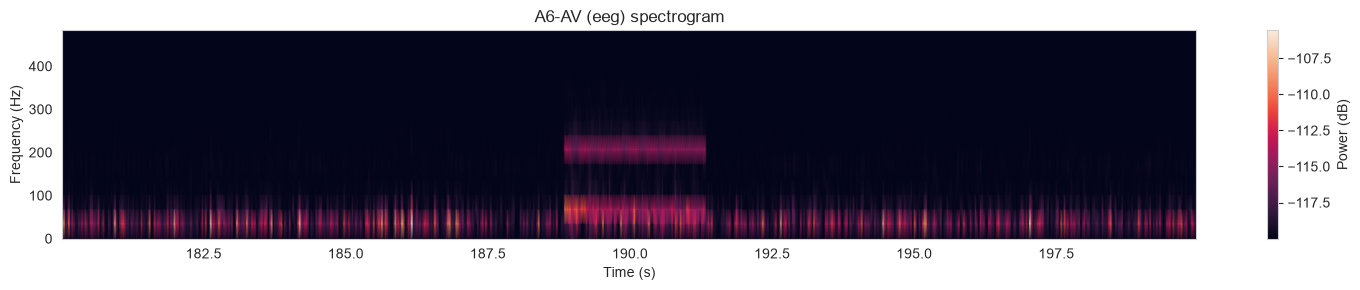

In [32]:
fig = plot_channel_spectrogram(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=1000,
    step_ms=500,
)
fig.show()
fig = plot_channel_spectrogram(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=30,
    step_ms=30,
)
fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/2384282841.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


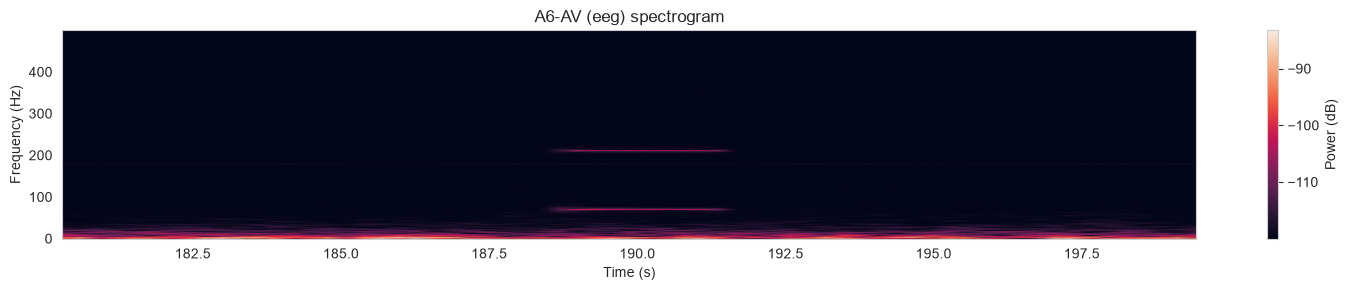

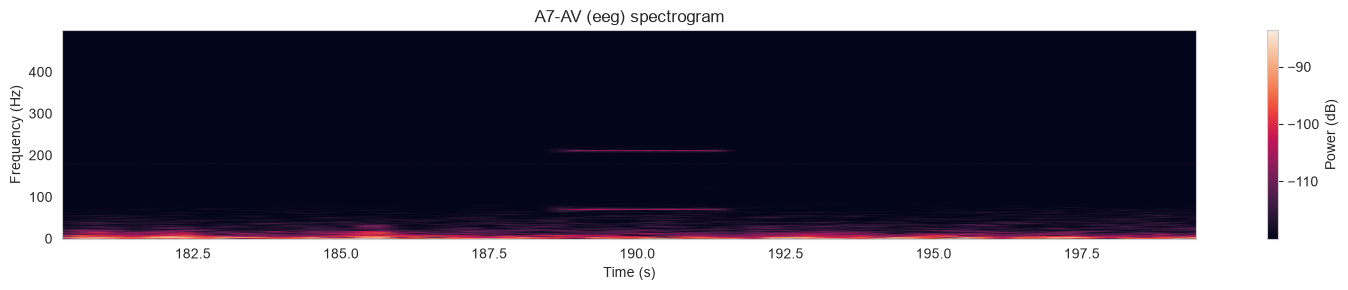

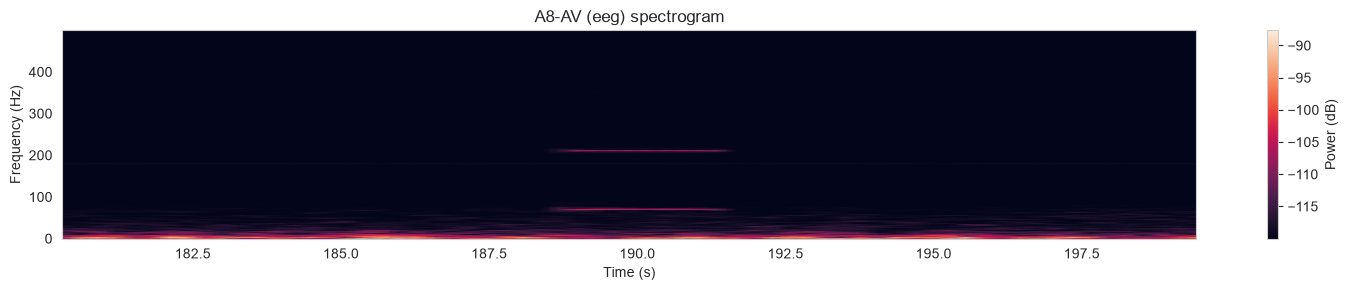

In [33]:
for ch_nbr in np.arange(5, 8):
    fig = plot_channel_spectrogram(
        signal,
        timestamps,
        ch_names,
        ch_types,
        channel_idx=ch_nbr,
        start_time=180,
        end_time=200,
    )
    fig.show()

In [34]:
ch_names[0]

np.str_('A1-AV')

In [35]:
on_channel = 5
(
    data.annotations.start[on_channel],
    data.annotations.end[on_channel],
    data.annotations.artifact[on_channel],
)

(np.float64(189.166), np.float64(189.214), np.int8(0))

plot power y and frequency x
fourier transform of the signal to get the frequency domain representation
check omni ieeg paper and zhang
check eymeric's code
wavelets
convolution

HFO shape accoridng to datasets, recording method
anat document in omni-ieeg dataset
250Hz can we detect them to not
segment by dataset and by sampling frequency - show
zhang 23 (implementation with code for it, take this as a baseline)
omni-ieeg paper:  reproduce pyHFO paper 0.8061 F1
zhang 25:

### 4. PyHFO preprocessing pipeline

Reproduces the preprocessing used by PyHFO's classification model (`omni_ieeg.event_model.pyhfo_classification`):

1. extract a 1 s raw waveform window centered on an HFO event and resample it to `fs`,
2. turn it into a `image_size` x `image_size` time-frequency image spanning `freq_range_hz` (the "cached" image),
3. crop that image down to `selected_freq_range_hz` / `selected_window_size_ms`, optionally jittering the crop's time position by up to `random_shift_ms` -- PyHFO's only train-time augmentation.

The image and crop code below is imported directly from `Omni-iEEG/omni_ieeg/event_model/pyhfo_classification` rather than reimplemented, so it matches the real training pipeline.

In [40]:
from scipy.signal import resample
import torch
from omni_ieeg.event_model.pyhfo_classification.features import hfo_feature_batch
from omni_ieeg.event_model.pyhfo_classification.model import PreProcessing

# Crop applied to the cached 224x224 image, plus the random time shift that is
# PyHFO's only train-time augmentation.
PREPROCESS = dict(
    image_size=224,
    fs=1000,
    freq_range_hz=[10, 500],
    event_length=1000,
    selected_window_size_ms=285,
    selected_freq_range_hz=[10, 290],
    random_shift_ms=45,
)
PREPROCESS

{'image_size': 224,
 'fs': 1000,
 'freq_range_hz': [10, 500],
 'event_length': 1000,
 'selected_window_size_ms': 285,
 'selected_freq_range_hz': [10, 290],
 'random_shift_ms': 45}

In [41]:
preprocessing = PreProcessing(
    image_size=PREPROCESS["image_size"],
    fs=PREPROCESS["fs"],
    freq_range_hz=PREPROCESS["freq_range_hz"],
    event_length=PREPROCESS["event_length"],
    selected_window_size_ms=PREPROCESS["selected_window_size_ms"],
    selected_freq_range_hz=PREPROCESS["selected_freq_range_hz"],
    random_shift_ms=PREPROCESS["random_shift_ms"],
)

In [42]:
def get_event_waveform(
    signal, timestamps, channel_idx, event_start_s, event_end_s, preprocess=PREPROCESS
):
    """Extract the `event_length` ms window centered on an HFO event and resample
    it to `fs` Hz, matching PyHFO's own extraction (`extract_waveforms` +
    `concate_edf(..., resample=...)` in Omni-iEEG)."""
    center_s = 0.5 * (event_start_s + event_end_s)
    half_len_s = preprocess["event_length"] / 1000 / 2
    keep = (timestamps >= center_s - half_len_s) & (timestamps < center_s + half_len_s)
    trace = signal[keep, channel_idx].astype(np.float64)
    n_target = int(preprocess["event_length"] / 1000 * preprocess["fs"])
    return resample(trace, n_target)

In [43]:
def pyhfo_images(waveform, preprocess=PREPROCESS):
    """Reproduce PyHFO's cached `image_size`x`image_size` spectrogram and its
    train-time crop (with and without the random time-shift augmentation)."""
    wave_t = torch.from_numpy(waveform).float().unsqueeze(0)
    spec, _amp = hfo_feature_batch(
        wave_t,
        sample_rate=preprocess["fs"],
        win_size=preprocess["image_size"],
        ps_MinFreqHz=preprocess["freq_range_hz"][0],
        ps_MaxFreqHz=preprocess["freq_range_hz"][1],
        device="cpu",
    )
    cached = spec[0].numpy()

    preprocessing.disable_random_shift()
    cropped_eval = preprocessing(spec[:, None])[0, 0].numpy()

    preprocessing.enable_random_shift()
    cropped_train = preprocessing(spec[:, None])[0, 0].numpy()

    return cached, cropped_eval, cropped_train

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_34983/2322963057.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


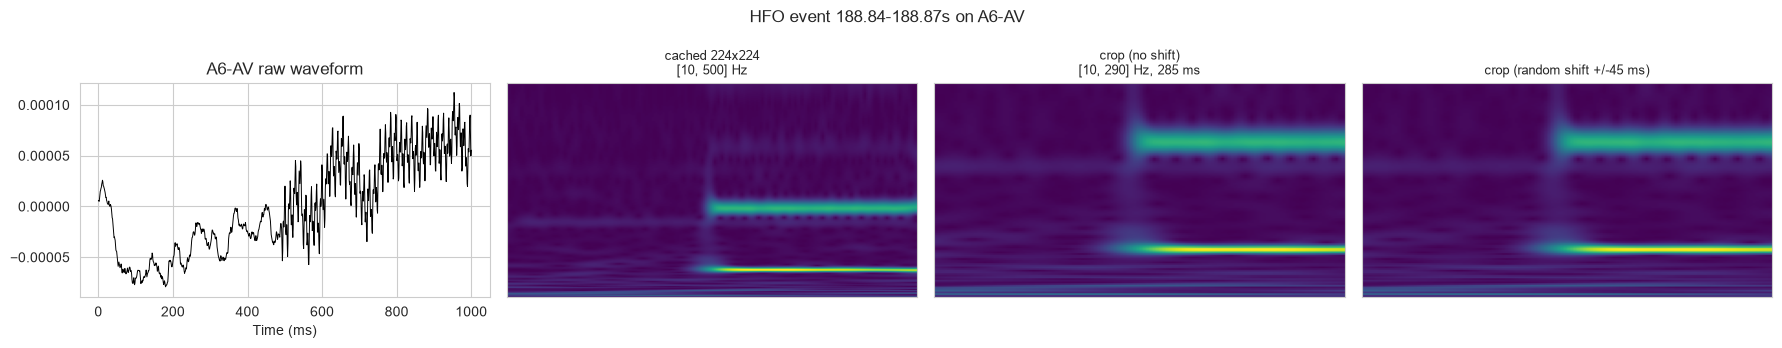

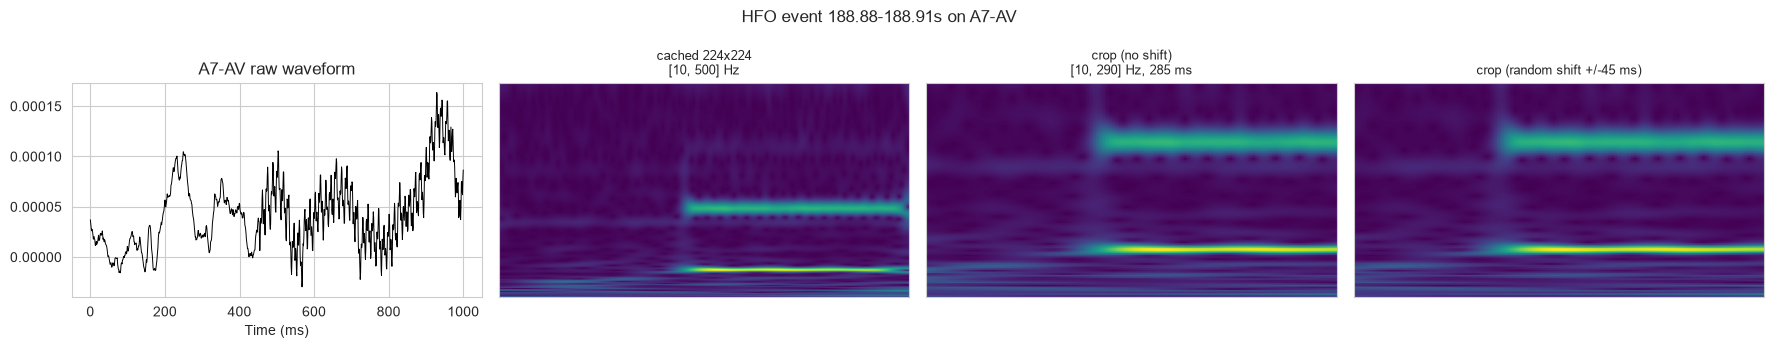

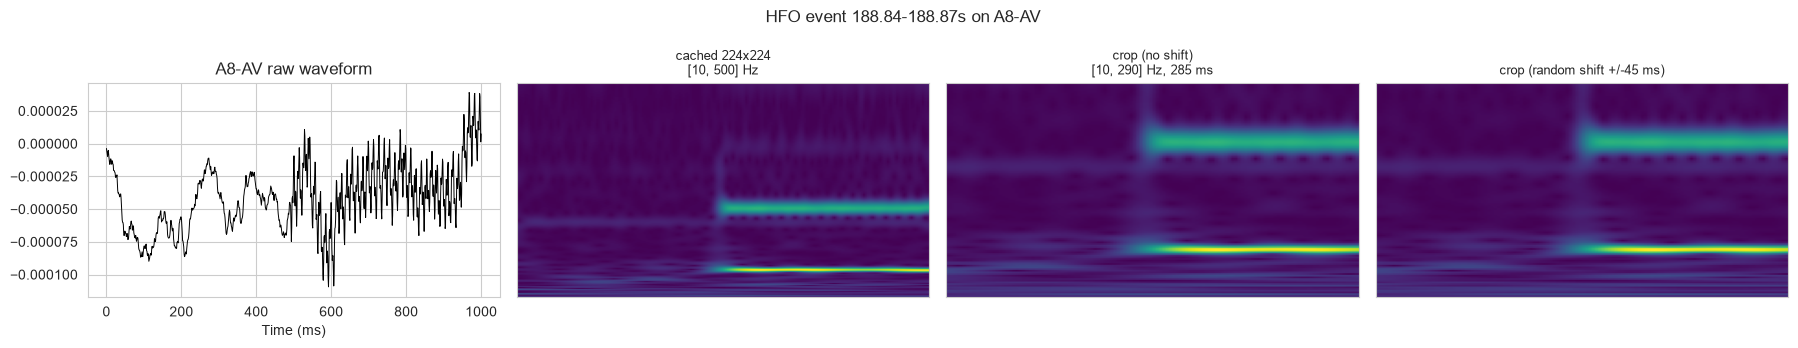

In [44]:
def plot_pyhfo_preprocessing(
    signal, timestamps, ch_names, annotations, channel_idx, event_idx=0, preprocess=PREPROCESS
):
    """Take the `event_idx`-th annotated HFO on `channel_idx` and show the raw
    waveform, the cached image, and the train-time crop (no shift vs. random shift)."""
    ch_name = ch_names[channel_idx]
    on_channel = annotations.channel.astype(str) == ch_name
    ev_starts = annotations.start[on_channel]
    ev_ends = annotations.end[on_channel]
    if len(ev_starts) == 0:
        print(f"No annotated events on {ch_name}")
        return None

    ev_start, ev_end = ev_starts[event_idx], ev_ends[event_idx]
    waveform = get_event_waveform(signal, timestamps, channel_idx, ev_start, ev_end, preprocess)
    cached, cropped_eval, cropped_train = pyhfo_images(waveform, preprocess)

    fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
    t_ms = np.linspace(0, preprocess["event_length"], len(waveform))
    axes[0].plot(t_ms, waveform, color="black", linewidth=0.7)
    axes[0].set_title(f"{ch_name} raw waveform")
    axes[0].set_xlabel("Time (ms)")

    for ax, img, title in zip(
        axes[1:],
        [cached, cropped_eval, cropped_train],
        [
            f"cached {preprocess['image_size']}x{preprocess['image_size']}\n{preprocess['freq_range_hz']} Hz",
            f"crop (no shift)\n{preprocess['selected_freq_range_hz']} Hz, {preprocess['selected_window_size_ms']} ms",
            f"crop (random shift +/-{preprocess['random_shift_ms']} ms)",
        ],
    ):
        ax.imshow(img, aspect="auto", cmap="viridis")
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"HFO event {ev_start:.2f}-{ev_end:.2f}s on {ch_name}")
    fig.tight_layout()
    return fig


for ch_nbr in np.arange(5, 8):
    fig = plot_pyhfo_preprocessing(signal, timestamps, ch_names, data.annotations, channel_idx=ch_nbr)
    if fig is not None:
        fig.show()

### 5. Comparing HFO event types and recording modality

Compares annotated HFO events across:
- **event type**: artifact (doctor-flagged false positive), spHFO (co-occurs with a spike), isolated HFO,
- **recording technology**: ECoG vs SEEG (`device.recording_tech`, one value per recording).

Events differ hugely in raw amplitude across patients/channels/modalities, so plotting many raw waveforms
superposed on one axis mostly produces unreadable clutter. This notebook uses **small multiples**
(a grid, one panel per event) as the default view for browsing many examples, and a separate
**normalized overlay** (each waveform z-scored, plotted at low alpha, with the group mean in bold) as the
"superposed" view for comparing average shape across a group -- normalizing is what makes that superposition
actually legible.

As more patients are added to `data/raw/omni_ieeg`, re-run `pipelines/omni_ieeg/pipeline.py` (or `brainsets prepare`,
see the README) and this section will automatically pick up any newly processed `.h5` file that has annotations.

In [ ]:
import pandas as pd


def scan_annotated_recordings(bids_root):
    """List every recording under `bids_root` with its HFO-annotation count,
    recording technology, and dataset -- read directly via h5py so this stays
    cheap even as more (mostly un-annotated) recordings are added."""
    rows = []
    for fname in sorted(os.listdir(bids_root)):
        if not fname.endswith(".h5"):
            continue
        with h5py.File(os.path.join(bids_root, fname), "r") as f:
            n_ann = f["annotations"]["start"].shape[0] if "start" in f.get("annotations", {}) else 0
            rows.append(
                dict(
                    file=fname,
                    n_annotations=n_ann,
                    recording_tech=f["device"].attrs.get("recording_tech"),
                    dataset_name=f.attrs.get("dataset_name"),
                    fs=f["ieeg"].attrs.get("sampling_rate"),
                )
            )
    return pd.DataFrame(rows)


recordings = scan_annotated_recordings(BIDS_ROOT)
print(recordings)
print("\nannotated events per recording technology:")
print(recordings.groupby("recording_tech")["n_annotations"].sum())

In [ ]:
def collect_hfo_examples(bids_root, recordings, max_events_per_type=15, preprocess=PREPROCESS):
    """Extract up to `max_events_per_type` annotated HFO waveforms per
    (recording, event_type), sampled per type rather than uniformly over all
    events -- artifacts are rare (~1% here), so a blind uniform subsample
    would silently drop them from the comparison."""
    examples = []
    annotated = recordings[recordings["n_annotations"] > 0]
    for _, row in annotated.iterrows():
        with h5py.File(os.path.join(bids_root, row["file"]), "r") as f:
            file_data = Data.from_hdf5(f, lazy=False)
        ch_names = file_data.channels.id.astype(str)
        sig = file_data.ieeg.signal
        ts = file_data.ieeg.timestamps
        ann = file_data.annotations
        ann_channel = ann.channel.astype(str)
        ann_detector = ann.detector.astype(str)

        event_types = np.where(
            np.asarray(ann.artifact) == 1,
            "artifact",
            np.where(np.asarray(ann.spike) == 1, "spHFO", "isolated HFO"),
        )
        for event_type in np.unique(event_types):
            type_idx = np.where(event_types == event_type)[0]
            sample_idx = type_idx[np.linspace(0, len(type_idx) - 1, min(len(type_idx), max_events_per_type)).astype(int)]
            print(f"{row['file']}: sampling {len(sample_idx)}/{len(type_idx)} '{event_type}' events")

            for i in sample_idx:
                ch_idx = np.where(ch_names == ann_channel[i])[0]
                if len(ch_idx) == 0:
                    continue
                waveform = get_event_waveform(sig, ts, ch_idx[0], ann.start[i], ann.end[i], preprocess)
                examples.append(
                    dict(
                        file=row["file"],
                        recording_tech=row["recording_tech"],
                        dataset_name=row["dataset_name"],
                        channel=ann_channel[i],
                        detector=ann_detector[i],
                        event_type=event_type,
                        waveform=waveform,
                    )
                )
    return examples


examples = collect_hfo_examples(BIDS_ROOT, recordings, max_events_per_type=15)
print(f"\ncollected {len(examples)} example events total")

In [ ]:
def plot_event_grid(examples, group_key, n_per_group=12, ncols=6, preprocess=PREPROCESS):
    """Small multiples of raw waveforms, one panel per event, grouped by
    `group_key` (e.g. "event_type", "recording_tech"). Always prints how many
    events exist per group vs. how many are actually plotted."""
    groups = {}
    for ex in examples:
        groups.setdefault(ex[group_key], []).append(ex)

    for group_name, group_examples in groups.items():
        shown = group_examples[:n_per_group]
        t_ms = np.linspace(0, preprocess["event_length"], len(shown[0]["waveform"]))
        nrows = int(np.ceil(len(shown) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 1.6 * nrows), sharex=True)
        axes = np.atleast_1d(axes).ravel()
        for ax, ex in zip(axes, shown):
            ax.plot(t_ms, ex["waveform"], color="black", linewidth=0.6)
            ax.set_title(ex["channel"], fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
        for ax in axes[len(shown):]:
            ax.axis("off")
        fig.suptitle(f"{group_key} = {group_name}  ({len(shown)}/{len(group_examples)} events shown)")
        fig.tight_layout()
        fig.show()


plot_event_grid(examples, group_key="event_type")
plot_event_grid(examples, group_key="recording_tech")

In [ ]:
def plot_group_overlay(examples, group_key, preprocess=PREPROCESS):
    """Normalized (z-scored) overlay of every event's waveform per group, with
    the group mean in bold -- a superposition view that stays legible across
    events of very different raw amplitude."""
    groups = {}
    for ex in examples:
        groups.setdefault(ex[group_key], []).append(ex)

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 3.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (group_name, group_examples) in zip(axes, groups.items()):
        traces = np.stack(
            [
                (ex["waveform"] - ex["waveform"].mean()) / (ex["waveform"].std() + 1e-9)
                for ex in group_examples
            ]
        )
        t_ms = np.linspace(0, preprocess["event_length"], traces.shape[1])
        ax.plot(t_ms, traces.T, color="steelblue", alpha=0.15, linewidth=0.7)
        ax.plot(t_ms, traces.mean(axis=0), color="black", linewidth=2, label="mean")
        ax.set_title(f"{group_key} = {group_name} (n={len(group_examples)})")
        ax.set_xlabel("Time (ms)")
        ax.legend()
    axes[0].set_ylabel("z-scored amplitude")
    fig.tight_layout()
    return fig


fig = plot_group_overlay(examples, group_key="event_type")
fig.show()
fig = plot_group_overlay(examples, group_key="recording_tech")
fig.show()